In [1]:
import os
import sys
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

In [2]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

from src.networks.DecoderPINN import PINN
from src.networks.Encoder import Encoder
from src.data.encoder_dataloader import load_encoder_data
from src.hyperparameters import hypers_uqvae as h
from src.visualization.pdeplots import N_GRID
from src.visualization.uqplots import propagate_and_plot_uncertainty_on_axes_sobol, plot_multiple_posterior_heatmaps

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

2026-10-03 16:33:35.426684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791038015.436101  223180 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791038015.438948  223180 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791038015.446831  223180 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791038015.446843  223180 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791038015.446844  223180 computation_placer.cc:177] computation placer alr

In [3]:
output_dir = 'models/pipeline_evolution/04_uq-vae'
results_dir = 'results/pipeline_evolution/04_uq-vae'
decoder_dir = 'models/pipeline_evolution/03_parametric_pinn'
data_dir = 'data/parametric/400x400'

os.makedirs(output_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

train_path = os.path.join(data_dir, 'train.npz')
val_path = os.path.join(data_dir, 'val.npz')
test_path = os.path.join(data_dir, 'test.npz')
scale_path = os.path.join(data_dir, 'u_scale.npy')
base_data_dir = os.path.dirname(data_dir)
sensor_idx_path = os.path.join(base_data_dir, 'sensor_idx.npy')

(_, _), (_, _), (y_obs_test, u_test), X_obs, sensor_idx, U_SCALE = load_encoder_data(
    train_path=train_path, val_path=val_path, test_path=test_path,
    scale_path=scale_path, n_sensors=h.N_SENSORS,
    region_bounds=h.SENSOR_REGION, sensor_idx_path=sensor_idx_path,
    noise_level=h.NOISE, dtype=number_type
)

y_test = tf.cast(y_obs_test, number_type)
u_test = tf.cast(u_test, number_type)
X_obs = tf.cast(X_obs, number_type)

[SENSORS] Used sensors saved in: data/parametric/sensor_idx.npy
Shape y_train: (799, 200)  |  Shape u_train: (799, 2)
Shape y_val:   (99, 200)  |  Shape u_val:   (99, 2)
Shape y_test:  (101, 200)  |  Shape u_test:  (101, 2)


I0000 00:00:1791038018.410486  223180 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


In [4]:
# Decoder (PINN)
decoder_pinn = PINN(h.N_NEURONS_DECODER, U_SCALE)
decoder_pinn(tf.zeros((1, 4), dtype=number_type))
decoder_weights_path = os.path.join(decoder_dir, 'decoder_lbfgs.weights.h5')
if not os.path.exists(decoder_weights_path):
    decoder_weights_path = os.path.join(decoder_dir, 'decoder_adam.weights.h5')
decoder_pinn.load_weights(decoder_weights_path)
decoder_pinn.trainable = False
print(f"Decoder weights loaded: {decoder_weights_path}")

# Encoder VAE
encoder_vae = Encoder(n_neurons=h.N_NEURONS_ENCODER, latent_dim=h.D_z)
encoder_vae(tf.zeros((1, h.N_SENSORS), dtype=number_type))
encoder_weights_path = os.path.join(output_dir, 'encoder_adam.weights.h5')
encoder_vae.load_weights(encoder_weights_path)
print(f"Encoder weights loaded: {encoder_weights_path}")

Decoder weights loaded: models/pipeline_evolution/03_parametric_pinn/decoder_lbfgs.weights.h5
Encoder weights loaded: models/pipeline_evolution/04_uq-vae/encoder_adam.weights.h5


In [5]:
qz_test = encoder_vae(y_test)

u_pred_mean = tf.cast(qz_test.mean(), number_type).numpy()
u_pred_cov = tf.cast(qz_test.covariance(), number_type).numpy()

Uncertainty Propagation (Sobol) for sample 9 (True cx=0.595, cy=0.505)...
Uncertainty Propagation (Sobol) for sample 27 (True cx=0.522, cy=0.488)...
Uncertainty Propagation (Sobol) for sample 40 (True cx=0.368, cy=0.492)...
Uncertainty Propagation (Sobol) for sample 41 (True cx=0.414, cy=0.533)...
Uncertainty Propagation (Sobol) for sample 45 (True cx=0.507, cy=0.599)...


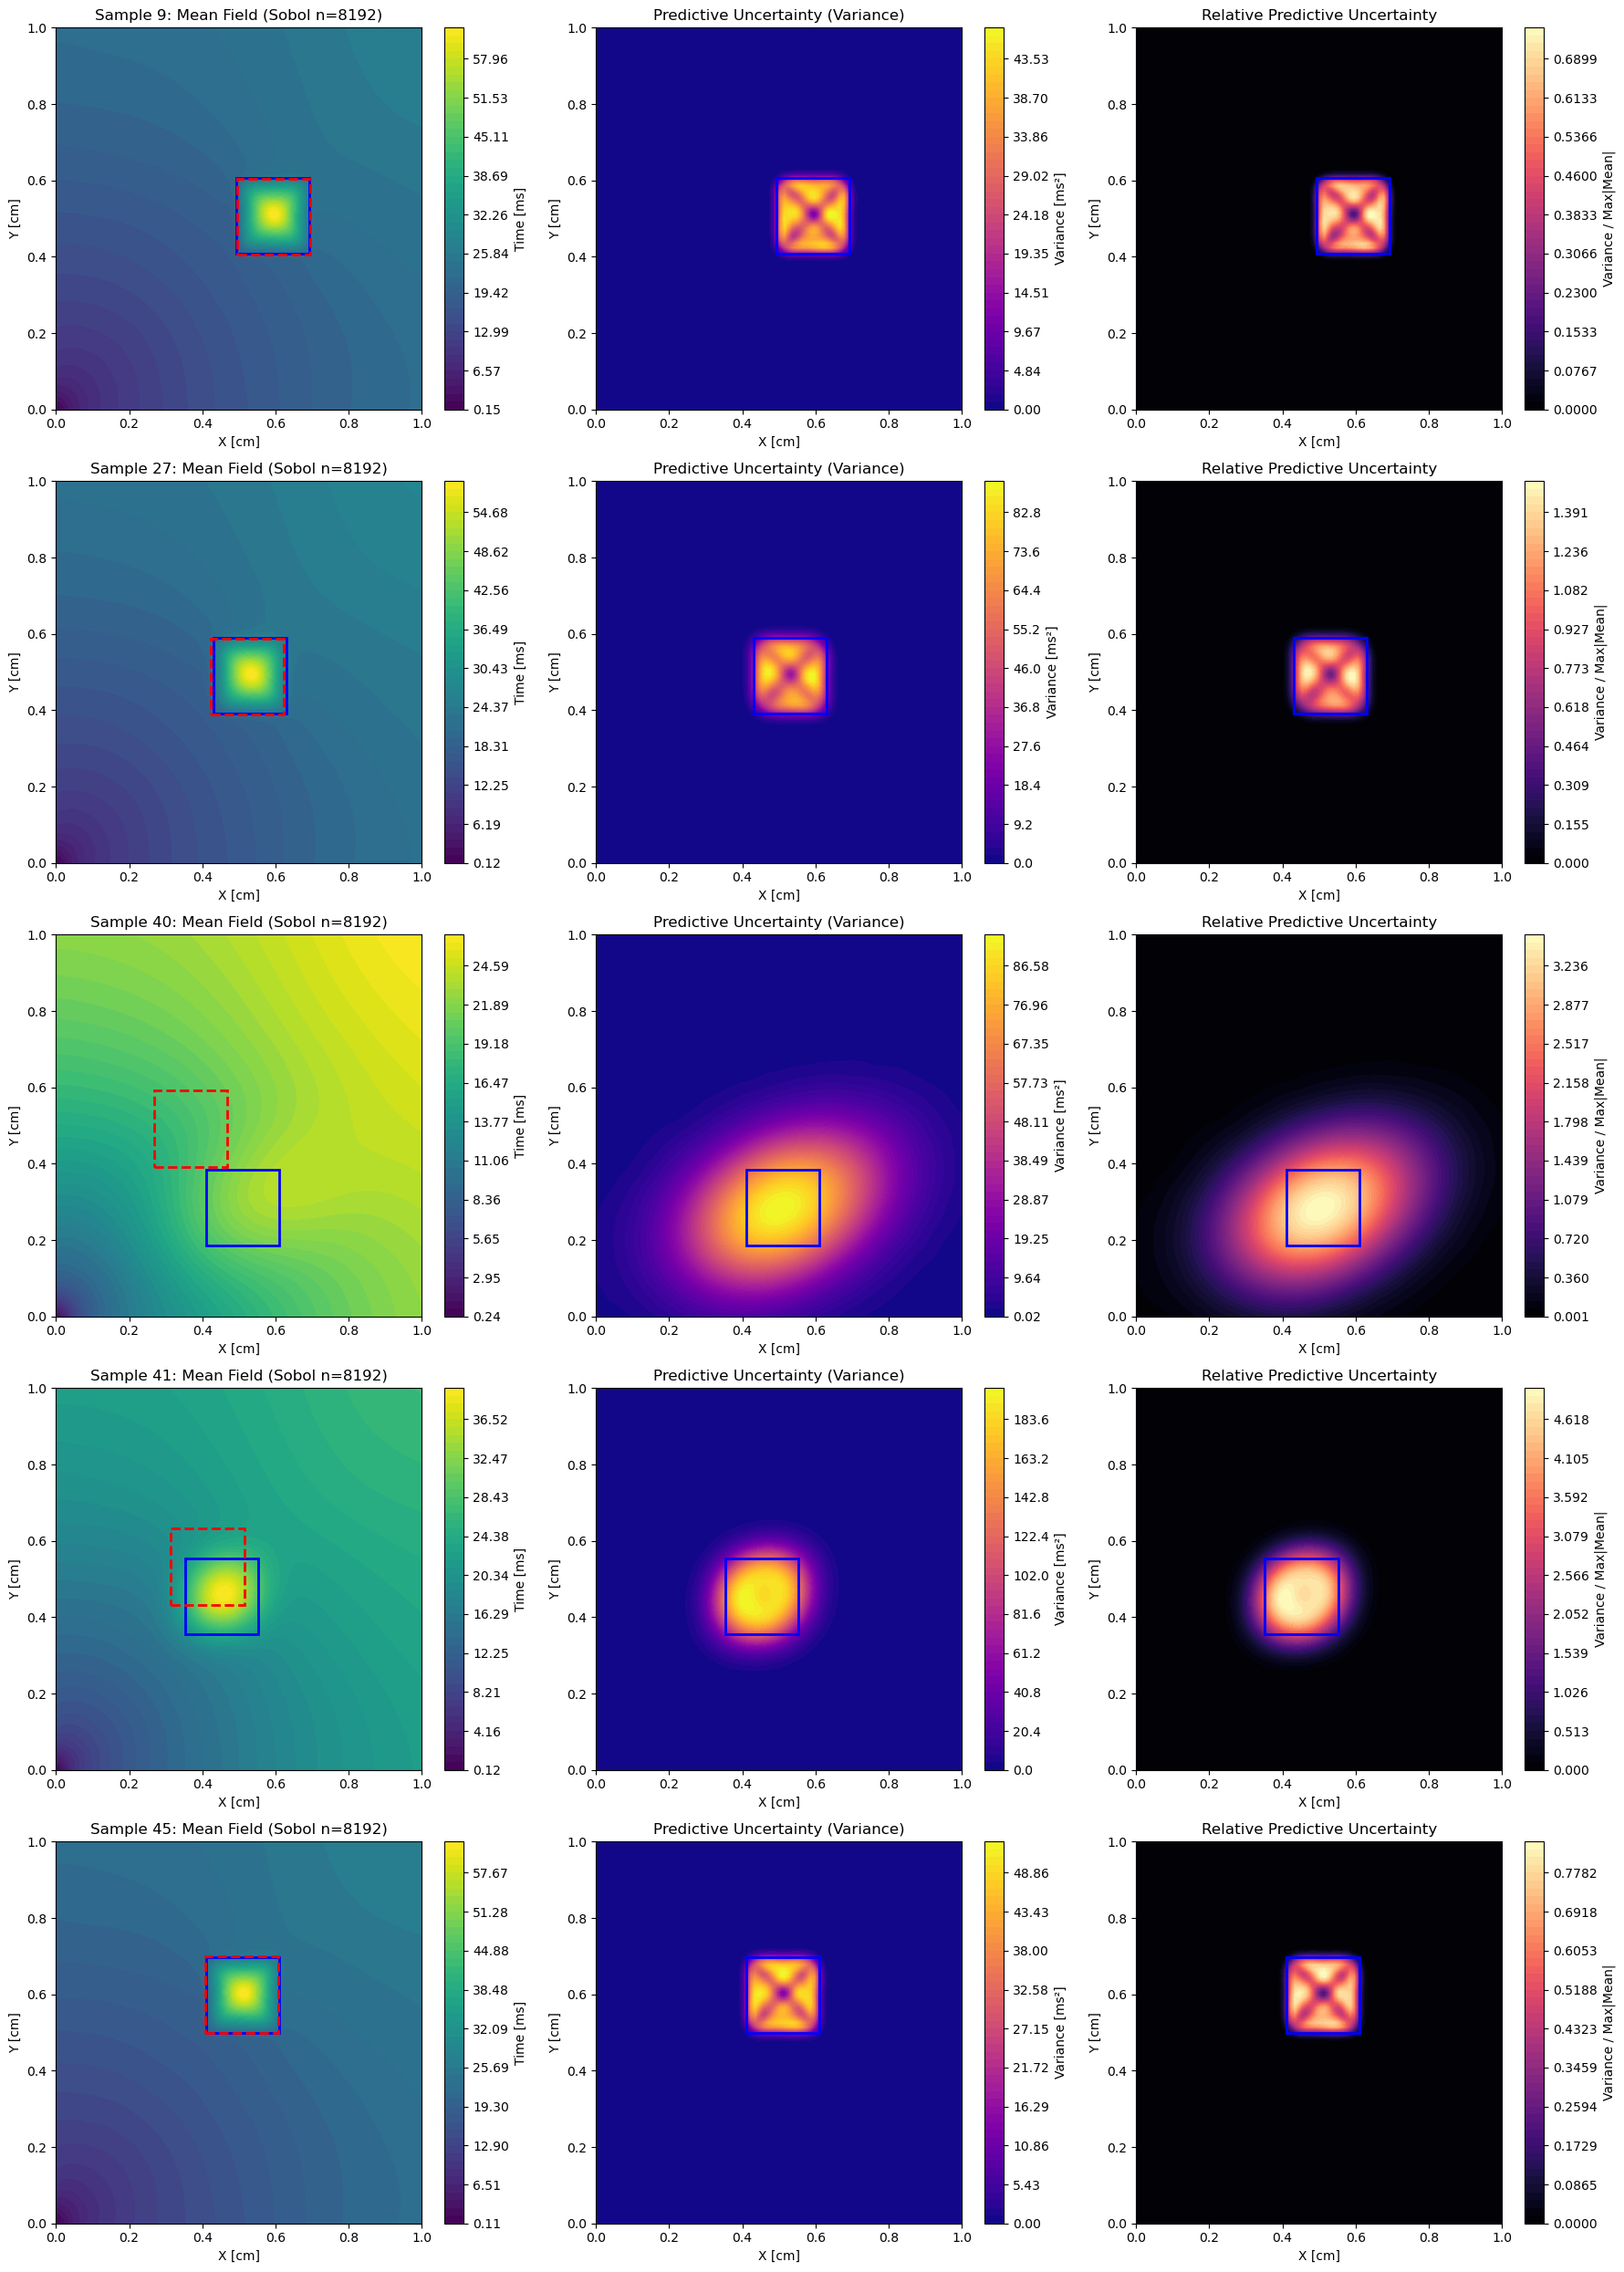

In [6]:
sample_indices = [9,27,40,41,45,80]
sample_indices_prop = sample_indices[:5] 
fig_prop_sobol, axes_prop_sobol = plt.subplots(5, 3, figsize=(18, 25))

for i, idx in enumerate(sample_indices_prop):
    propagate_and_plot_uncertainty_on_axes_sobol(
        decoder_pinn=decoder_pinn,
        qz_val=qz_test,
        u_pred_mean=u_pred_mean,
        u_true=u_test,
        sample_idx=idx,
        axes=axes_prop_sobol[i],      
        U_SCALE=U_SCALE,
        K_samples=8192,
        number_type=number_type
    )

plt.tight_layout()
fig_prop_sobol.savefig(os.path.join(results_dir, "uncertainty_propagation.pdf"), format='pdf', bbox_inches='tight')
plt.show()

I0000 00:00:1791038170.197259  223180 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5df5a563b310


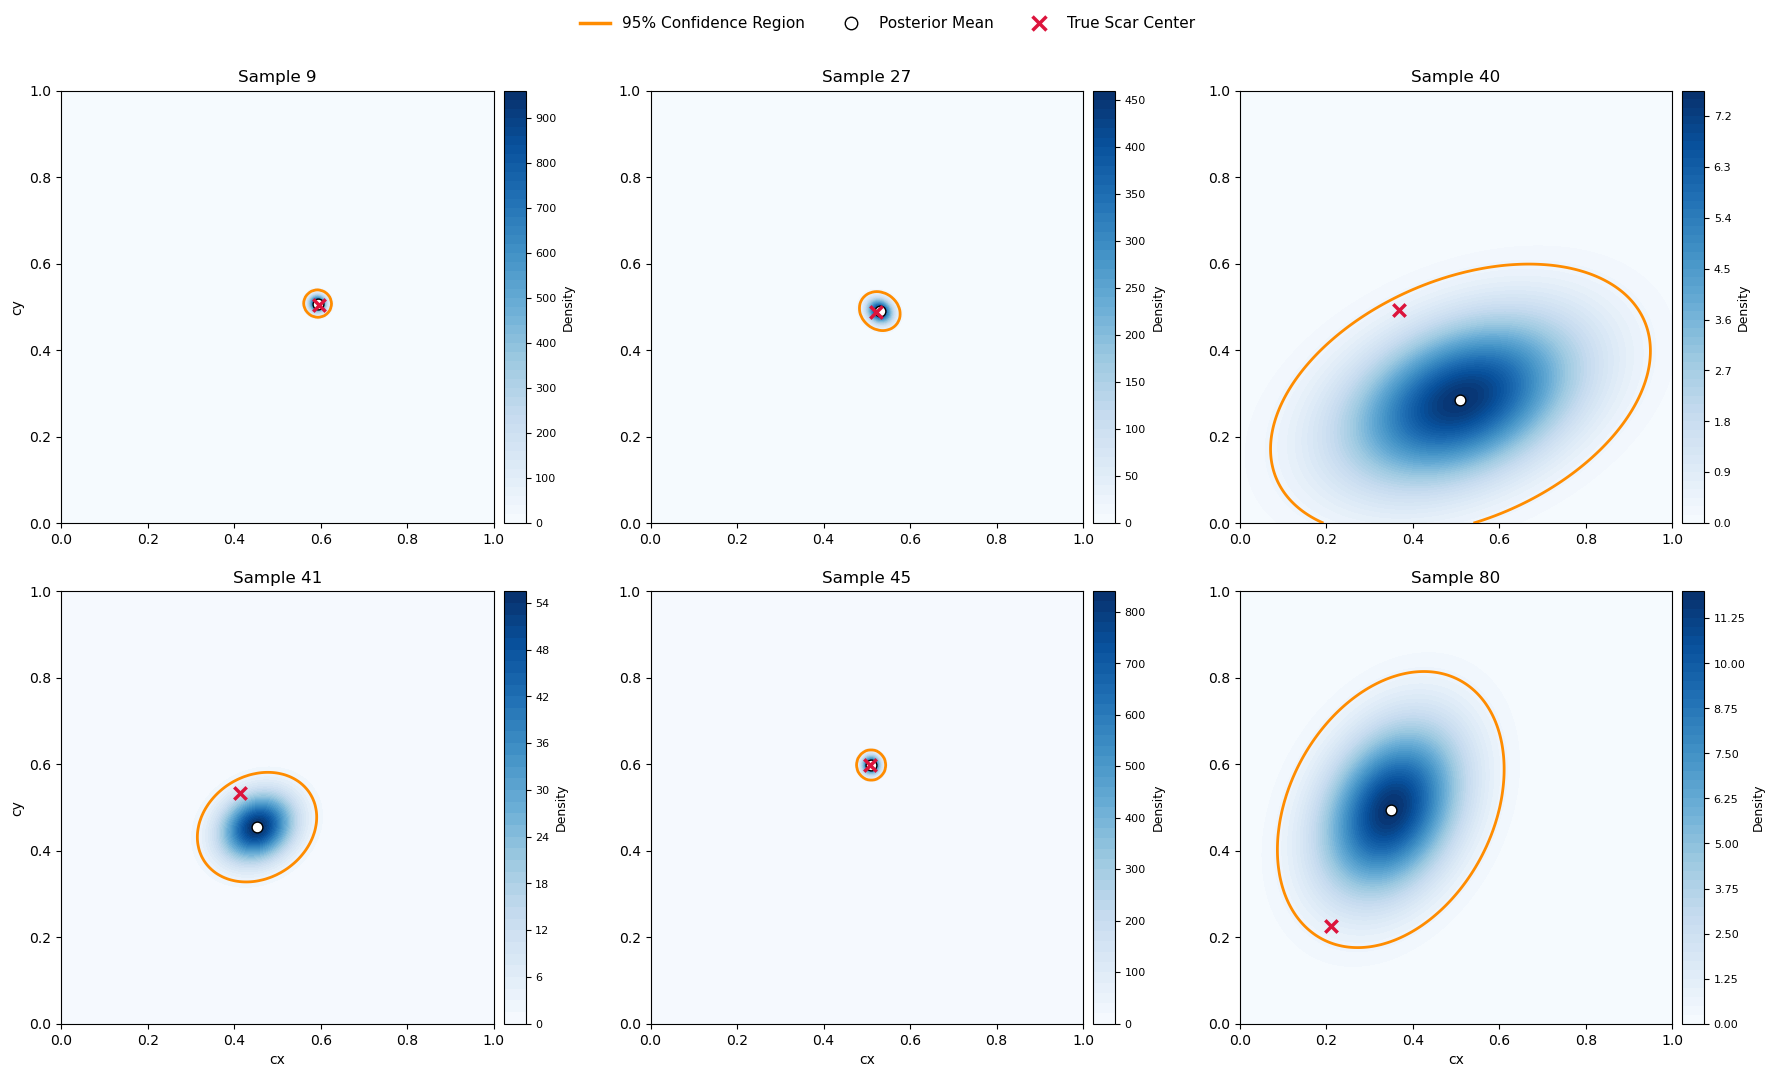

In [7]:
sample_indices = [9,27,40,41,45,80]
plot_multiple_posterior_heatmaps(qz_val=qz_test, u_true=u_test, sample_indices=sample_indices)
fig_heatmaps = plt.gcf()
#plt.tight_layout()
fig_heatmaps.savefig(os.path.join(results_dir, "posterior_heatmaps.pdf"), format='pdf', bbox_inches='tight')
plt.show()